# S10 — Student exercise: subscription customer revenue

**35 minutes, individual work. AI is allowed. No new code is required.**

The subscription service wants to compare annual revenue by acquisition channel before allocating a retention budget. Run all cells to produce evidence. Read `docs/case_brief.md` and the source evidence. Fill in the decision table and conclusion cells.

Your deliverable: four justified quality decisions, a comparison of two scenarios, and one business recommendation with evidence and limits. Do not present assumed revenue as an observed fact.

In [1]:
SOURCE_FILE = "subscription_customers_raw.csv"
ROLE_FOLDER = "Students"

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Find the case folder from its notebook, Session10 or package root.
folder_options = [Path.cwd(), Path.cwd().parent]
for parent in [Path.cwd(), Path.cwd().parent]:
    folder_options.append(parent / ROLE_FOLDER / "Session10")
CASE = next((p for p in folder_options if (p / "data" / SOURCE_FILE).exists()), None)
if CASE is None:
    raise FileNotFoundError("Keep notebooks, data and docs in the extracted Session10 folder.")
DATA = CASE / "data"
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
plt.rcParams.update({"figure.figsize": (9, 4), "font.size": 13})
TEAL, BLUE, CORAL = "#089599", "#2C77AE", "#F16A5D"
print("Data folder:", DATA)

Data folder: /workspace/scratch/6de5aa521006/output/S10_notebooks_and_data/Students/Session10/data


## 1. Look at the data and source evidence

In [2]:
raw = pd.read_csv(DATA / SOURCE_FILE, dtype={"customer_id": "string", "acquisition_channel": "string", "customer_name": "string", "postcode": "string", "source_batch": "string"})
evidence = pd.read_csv(DATA / "source_evidence.csv")
identity_candidates = pd.read_csv(DATA / "identity_candidates.csv", dtype={"shared_postcode": "string"})
display(raw)
display(raw.dtypes.to_frame("dtype"))
display(evidence)
display(identity_candidates)
print("Raw rows:", len(raw), "Unique customer IDs:", raw["customer_id"].nunique())

Raw rows: 9 Unique customer IDs: 8


,customer_id,acquisition_channel,annual_revenue_eur,customer_name,postcode,source_batch
0,D01,Digital,100.0,Liam Gray,28001,S_2026_annual
1,D02,Digital,140.0,Chloe Perez,28002,S_2026_annual
2,D03,Digital,160.0,Noah Ruiz,28003,S_2026_annual
3,D04,Digital,800.0,Aster Studio,28004,S_2026_annual
4,L01,Legacy,120.0,Eva Simon,28005,S_2026_annual
5,L02,Legacy,180.0,Leo Dubois,28006,S_2026_annual
6,L03,Legacy,NaN,Marta Lopez,28007,S_2026_annual
7,L04,Legacy,NaN,M. López,28007,S_2026_annual
8,D02,Digital,140.0,Chloe Perez,28002,S_2026_annual


,dtype
customer_id,string[python]
acquisition_channel,string[python]
annual_revenue_eur,float64
customer_name,string[python]
postcode,string[python]
source_batch,string[python]


,evidence_id,related_record,source,evidence
0,E01,D02,Export log,The same customer snapshot was replayed once in the annual export.
1,E02,D04,Verified annual contract,Net invoiced annual revenue is EUR800. No OCR or decimal error was found.
2,E03,L03 / L04,CRM inspection,Similar names and the same postcode. No verified shared identity link is available.
3,E04,Legacy channel,Invoice export description,The Legacy channel uses an older export process. Some invoice matches fail; the affected revenue values have not been reconciled.


,customer_a,customer_b,shared_postcode,identity_link_verified
0,L03,L04,28007,False


**Record your interpretation:** What is the grain? What does missing revenue mean? Which additional source evidence matters before changing a record?

**Your answer:** ...

## 2. Inspect exact repetitions and a candidate identity pair

In [3]:
# These are diagnostic flags. No source file is modified.
analytical_fields = ["customer_id", "acquisition_channel", "annual_revenue_eur"]
exact_flag = raw.duplicated(subset=analytical_fields, keep=False)
key_flag = raw.duplicated(subset=["customer_id"], keep=False)
display(raw.loc[exact_flag])
display(raw.loc[key_flag])
display(raw.loc[raw["customer_id"].isin(identity_candidates[["customer_a", "customer_b"]].to_numpy().ravel())])

,customer_id,acquisition_channel,annual_revenue_eur,customer_name,postcode,source_batch
1,D02,Digital,140.0,Chloe Perez,28002,S_2026_annual
8,D02,Digital,140.0,Chloe Perez,28002,S_2026_annual


,customer_id,acquisition_channel,annual_revenue_eur,customer_name,postcode,source_batch
1,D02,Digital,140.0,Chloe Perez,28002,S_2026_annual
8,D02,Digital,140.0,Chloe Perez,28002,S_2026_annual


,customer_id,acquisition_channel,annual_revenue_eur,customer_name,postcode,source_batch
6,L03,Legacy,NaN,Marta Lopez,28007,S_2026_annual
7,L04,Legacy,NaN,M. López,28007,S_2026_annual


## 3. A provisional working view for comparisons
The next cell collapses exact repetitions of the analytical fields in a separate working view. This makes comparisons at the expected customer grain possible. The raw data stay intact. You still need to explain whether the source evidence justifies this choice for the final handover. Similar names are not collapsed.

Working-view missing revenue (%): 25.0
Raw-row missing revenue (%): 22.22


,customers,observed_revenue,missing_revenue,missing_pct
acquisition_channel,,,,
Digital,4,4,0,0.0
Legacy,4,2,2,50.0


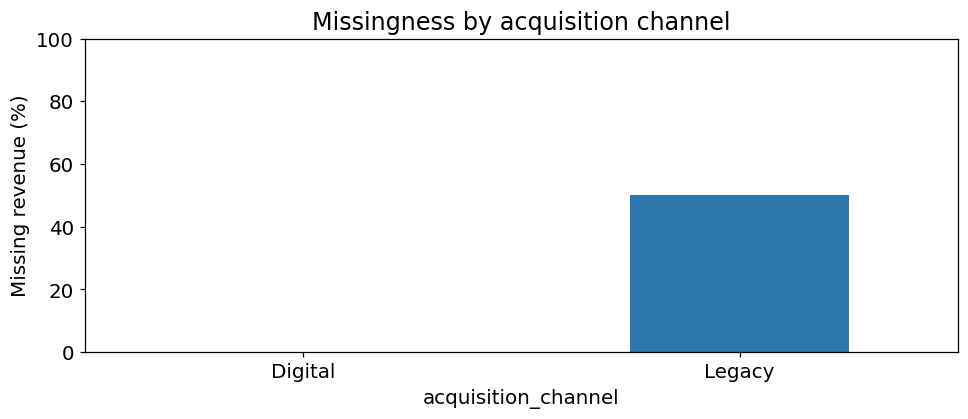

In [4]:
analysis = raw.drop_duplicates(subset=analytical_fields).copy()
assert analysis["customer_id"].is_unique, "A conflicting annual snapshot needs investigation before these comparisons."
analysis["revenue_missing"] = analysis["annual_revenue_eur"].isna()
missing_profile = analysis.groupby("acquisition_channel").agg(
    customers=("customer_id", "size"), observed_revenue=("annual_revenue_eur", "count"),
    missing_revenue=("revenue_missing", "sum"), missing_rate=("revenue_missing", "mean")
)
missing_profile["missing_pct"] = missing_profile.pop("missing_rate") * 100
display(missing_profile)
print("Working-view missing revenue (%):", analysis["revenue_missing"].mean() * 100)
print("Raw-row missing revenue (%):", round(raw["annual_revenue_eur"].isna().mean() * 100, 2))
missing_profile["missing_pct"].plot.bar(color=[TEAL, BLUE], ylabel="Missing revenue (%)", rot=0)
plt.ylim(0, 100)
plt.title("Missingness by acquisition channel")
plt.tight_layout()
plt.show()

**Your diagnosis:** Which missingness mechanisms are plausible? State the evidence, one alternative explanation, and one useful source check. Do not assign a mechanism solely from the chart.

**Your answer:** ...

## 4. Who disappears under complete-case selection?

Working customers: 8 Complete revenue customers: 6


,All customers (%),Complete cases (%)
acquisition_channel,,
Digital,50.0,66.67
Legacy,50.0,33.33


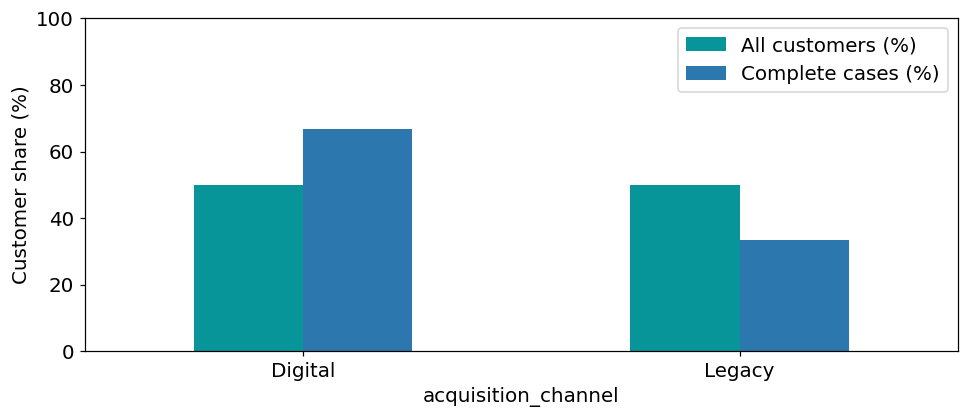

In [5]:
complete = analysis.dropna(subset=["annual_revenue_eur"])
composition = pd.concat({
    "All customers (%)": analysis["acquisition_channel"].value_counts(normalize=True) * 100,
    "Complete cases (%)": complete["acquisition_channel"].value_counts(normalize=True) * 100
}, axis=1).fillna(0).sort_index()
display(composition.round(2))
print("Working customers:", len(analysis), "Complete revenue customers:", len(complete))
composition.plot.bar(color=[TEAL, BLUE], ylabel="Customer share (%)", rot=0)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

## 5. Observed distributions and the large valid account

,size,count,mean,median,min,max
acquisition_channel,,,,,,
Digital,4,4,300.0,150.0,100.0,800.0
Legacy,4,2,150.0,150.0,120.0,180.0


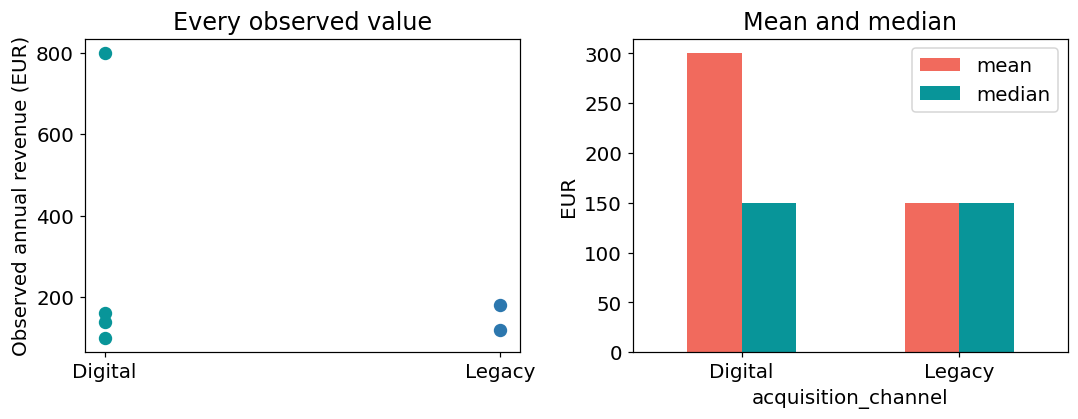

In [6]:
observed_summary = analysis.groupby("acquisition_channel")["annual_revenue_eur"].agg(["size", "count", "mean", "median", "min", "max"])
display(observed_summary.round(2))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, (channel, group) in enumerate(analysis.groupby("acquisition_channel")):
    values = group["annual_revenue_eur"].dropna()
    axes[0].scatter([i]*len(values), values, color=[TEAL, BLUE][i], s=60)
axes[0].set_xticks([0, 1], labels=sorted(analysis["acquisition_channel"].unique()))
axes[0].set(ylabel="Observed annual revenue (EUR)", title="Every observed value")
observed_summary[["mean", "median"]].plot.bar(ax=axes[1], color=[CORAL, TEAL], rot=0)
axes[1].set(ylabel="EUR", title="Mean and median")
plt.tight_layout()
plt.show()

**Your interpretation:** How does the large account affect a mean? Which indicator describes a typical client? Which values belong in realised total revenue?

**Your answer:** ...

## 6. Compare explicit assumptions

acquisition_channel,Digital,Legacy
observed,300.0,150.0
median_scenario,300.0,150.0
stress_scenario,300.0,375.0


acquisition_channel,Digital,Legacy
observed,4,2
median_scenario,4,4
stress_scenario,4,4


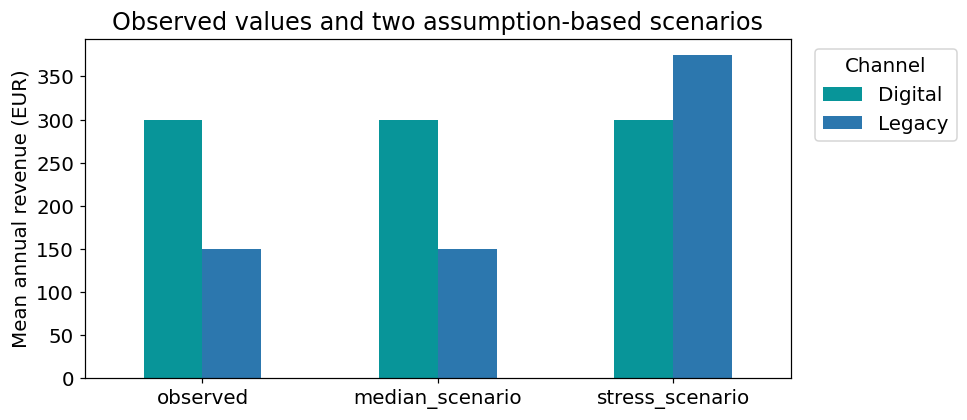

In [7]:
revenue = analysis["annual_revenue_eur"]
scenarios = analysis.copy()
scenarios["observed"] = revenue
scenarios["median_scenario"] = revenue.fillna(revenue.median())
# This stress assumption is prescribed for comparison, not asserted true.
scenarios["stress_scenario"] = revenue.fillna(600)
scenario_columns = ["observed", "median_scenario", "stress_scenario"]
means = scenarios.groupby("acquisition_channel")[scenario_columns].mean().T
usable_n = scenarios.groupby("acquisition_channel")[scenario_columns].count().T
display(means.round(2))
display(usable_n)
means.plot.bar(color=[TEAL, BLUE], rot=0, ylabel="Mean annual revenue (EUR)")
plt.legend(title="Channel", loc="upper left", bbox_to_anchor=(1.02, 1))
plt.title("Observed values and two assumption-based scenarios")
plt.tight_layout()
plt.show()

**Your sensitivity conclusion:** Does the channel comparison survive both assumptions? Explain what this comparison establishes and what it cannot establish.

**Your answer:** ...

## 7. Your four decisions

Complete this table. A pending investigation is a valid action if you explain the missing evidence.

|Issue|Evidence|Action|Reason and impact|
|---|---|---|---|
|Missing Legacy revenue|...|...|...|
|Repeated D02 snapshot|...|...|...|
|L03/L04 identity candidate|...|...|...|
|Verified EUR800 annual account|...|...|...|

## 8. Your recommendation and handover

Write one short paragraph answering the director's question. Include a numerical finding, the population it describes, one implication for the budget decision and a next step.

**Your recommendation:** ...

**What cannot be trusted:** ...

**AI audit:** If you used AI, name one suggestion you checked and what evidence you used. Otherwise write “AI not used”.

**Restart and Run All:** confirm the evidence reproduces before submission. Keep assumptions distinct from observations.